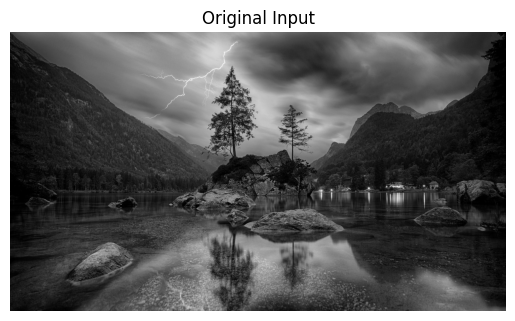

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_images(images, titles, cmap='gray'):
    plt.figure(figsize=(15, 5))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Load image in grayscale
img_path = 'sample.jpg' 
original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(original_img, cmap='gray')
plt.title("Original Input")
plt.axis('off')
plt.show()

Yash Agarwal 23BAI0011


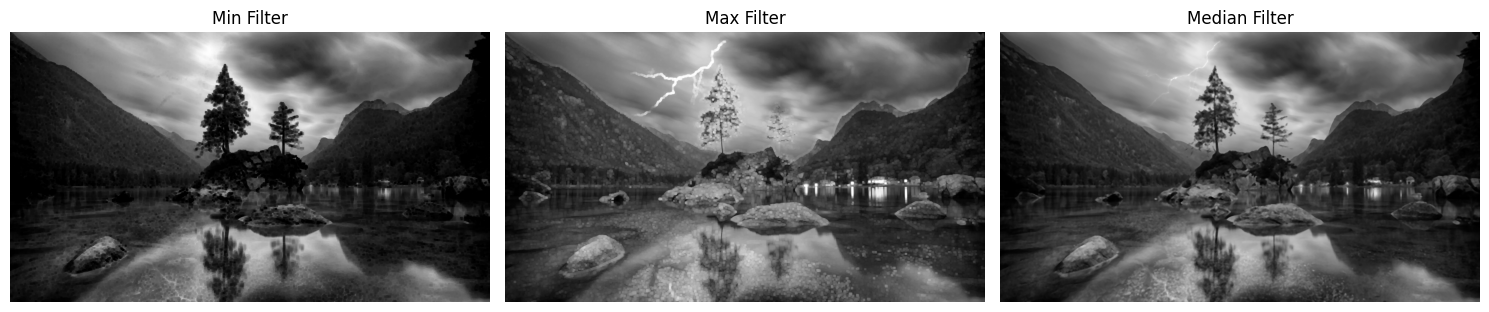

In [3]:
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), np.uint8)
# 1. Min Filter 
min_filter = cv2.erode(original_img, kernel)

# 2. Max Filter 
max_filter = cv2.dilate(original_img, kernel)

# 3. Median Filter
median_filter = cv2.medianBlur(original_img, kernel_size)
print("Yash Agarwal 23BAI0011")
show_images([ min_filter, max_filter, median_filter], 
            [ 'Min Filter', 'Max Filter', 'Median Filter'])

Yash Agarwal 23BAI0011


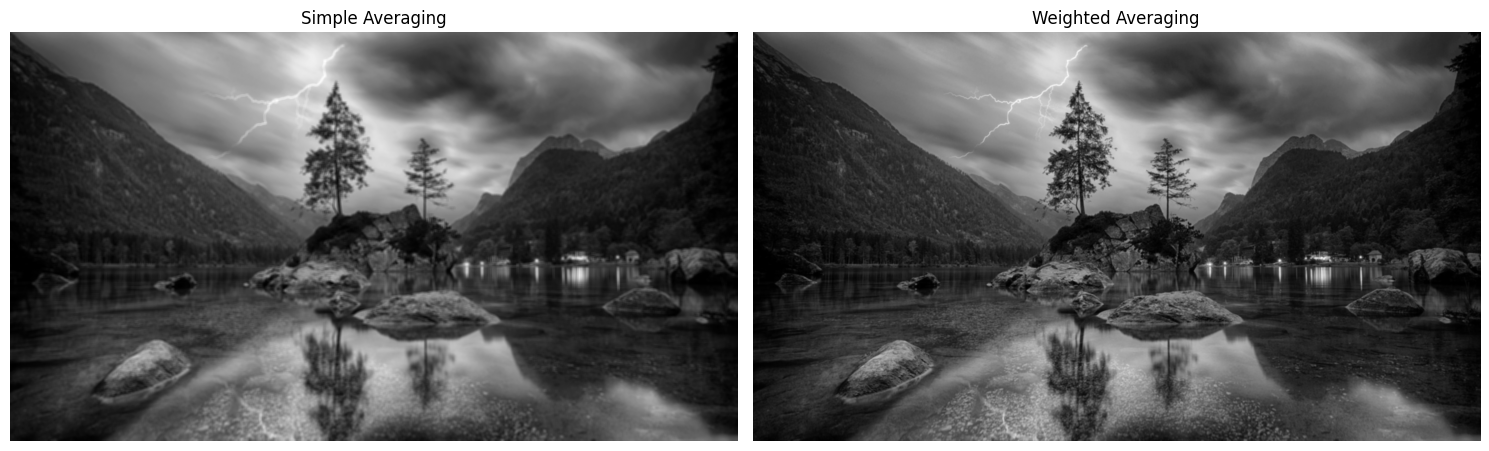

In [4]:
# 1. Simple Averaging 
simple_avg = cv2.blur(original_img, (5, 5))

weighted_kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16
weighted_avg = cv2.filter2D(original_img, -1, weighted_kernel)

print("Yash Agarwal 23BAI0011")
show_images([ simple_avg, weighted_avg], 
               ['Simple Averaging', 'Weighted Averaging'])

Yash Agarwal 23BAI0011


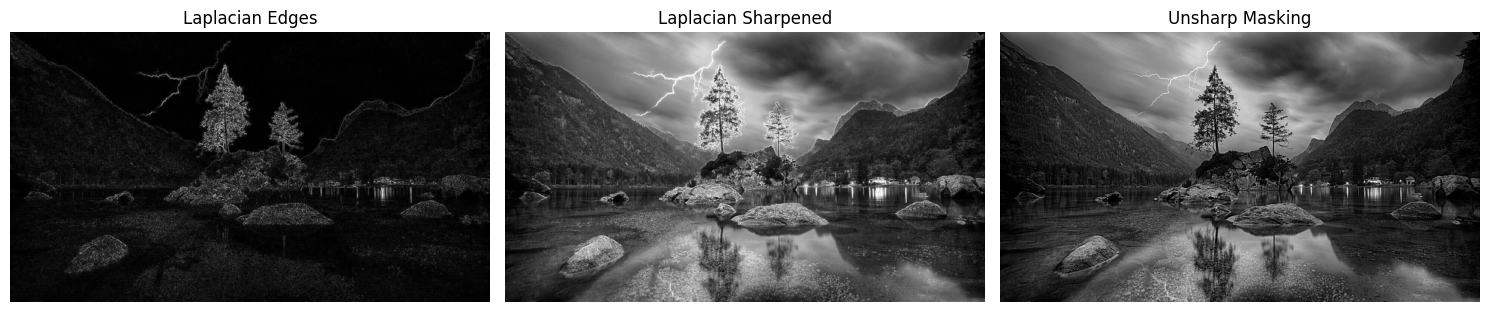

In [5]:
# 1. Laplacian Sharpening
laplacian = cv2.Laplacian(original_img, cv2.CV_64F)
laplacian_uint8 = cv2.convertScaleAbs(laplacian)
sharpened_laplacian = cv2.addWeighted(original_img, 1, laplacian_uint8, 1, 0)

# 2. Unsharp Masking
gaussian_blur = cv2.GaussianBlur(original_img, (9, 9), 10.0)
unsharp_mask = cv2.addWeighted(original_img, 1.5, gaussian_blur, -0.5, 0)

print("Yash Agarwal 23BAI0011")
show_images([ laplacian_uint8, sharpened_laplacian, unsharp_mask], 
               ['Laplacian Edges', 'Laplacian Sharpened', 'Unsharp Masking'])

Yash Agarwal 23BAI0011


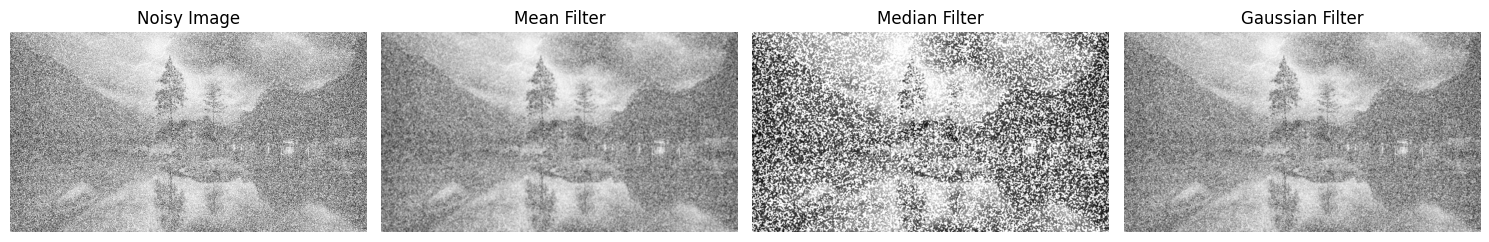

In [7]:
# 1. Add Gaussian Noise
mean = 0
sigma = 25
gauss = np.random.normal(mean, sigma, original_img.shape).astype('uint8')
noisy_img = cv2.add(original_img, gauss)

# 2. Apply Filters
filter_mean = cv2.blur(noisy_img, (5, 5))
filter_median = cv2.medianBlur(noisy_img, 5)
filter_gaussian = cv2.GaussianBlur(noisy_img, (5, 5), 0)

# Display
print("Yash Agarwal 23BAI0011")
show_images([noisy_img, filter_mean, filter_median, filter_gaussian], 
               ['Noisy Image', 'Mean Filter', 'Median Filter', 'Gaussian Filter'])

Yash Agarwal 23BAI0011


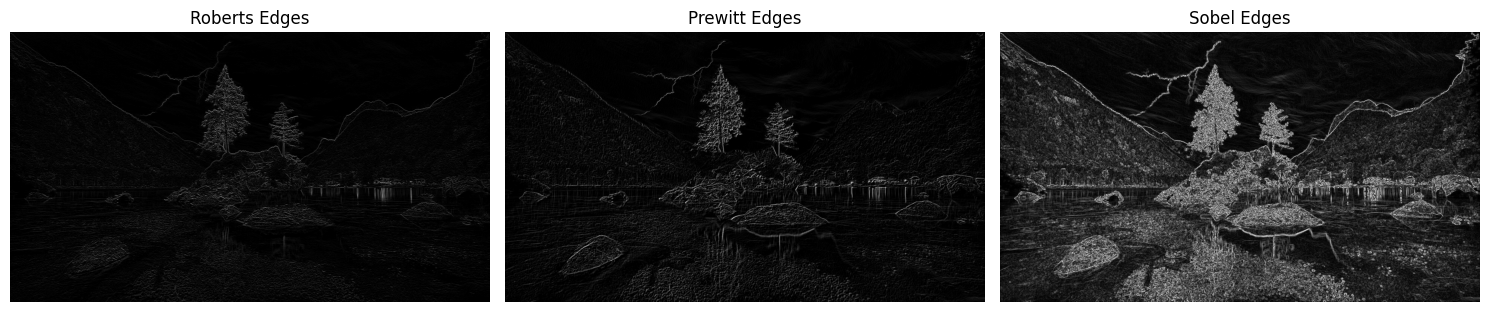

In [10]:
# 1. Roberts Kernels
roberts_cross_v = np.array( [[1, 0 ], [0,-1 ]] )
roberts_cross_h = np.array( [[0, 1 ], [-1, 0 ]] )

# 2. Prewitt Kernels
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

# Roberts
img_roberts_x = cv2.filter2D(original_img, -1, roberts_cross_v)
img_roberts_y = cv2.filter2D(original_img, -1, roberts_cross_h)
img_roberts = cv2.addWeighted(img_roberts_x, 0.5, img_roberts_y, 0.5, 0)

# Prewitt
img_prewitt_x = cv2.filter2D(original_img, -1, prewitt_x)
img_prewitt_y = cv2.filter2D(original_img, -1, prewitt_y)
img_prewitt = cv2.addWeighted(img_prewitt_x, 0.5, img_prewitt_y, 0.5, 0)

# Sobel
img_sobel_x = cv2.Sobel(original_img, cv2.CV_64F, 1, 0, ksize=3)
img_sobel_y = cv2.Sobel(original_img, cv2.CV_64F, 0, 1, ksize=3)
img_sobel = cv2.magnitude(img_sobel_x, img_sobel_y)
img_sobel = np.uint8(img_sobel)

# Contrast Stretching on Edges
def contrast_stretch(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

final_roberts = contrast_stretch(img_roberts)
final_prewitt = contrast_stretch(img_prewitt)
final_sobel = contrast_stretch(img_sobel)

# Display
print("Yash Agarwal 23BAI0011")
show_images([final_roberts, final_prewitt, final_sobel], 
               ['Roberts Edges', 'Prewitt Edges', 'Sobel Edges'])

Yash Agarwal 23BAI0011


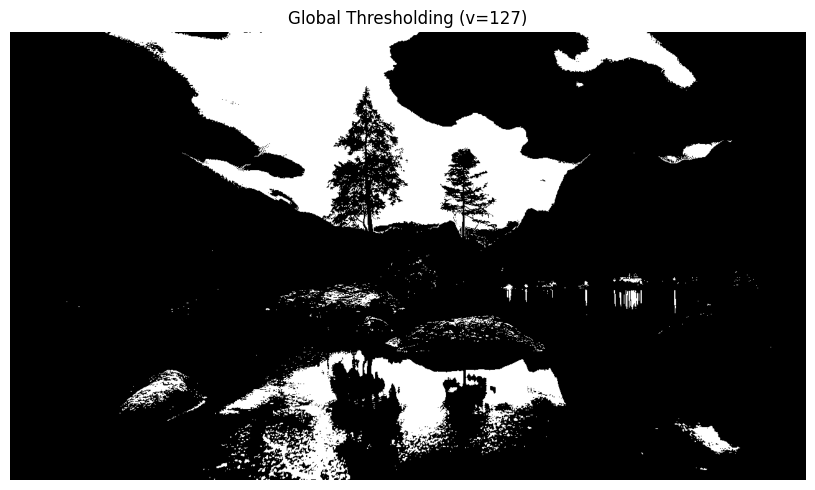

In [12]:
# Global Thresholding
ret, global_thresh = cv2.threshold(original_img, 127, 255, cv2.THRESH_BINARY)

# Display
print("Yash Agarwal 23BAI0011")
show_images([ global_thresh], 
               [ 'Global Thresholding (v=127)'])

Yash Agarwal 23BAI0011


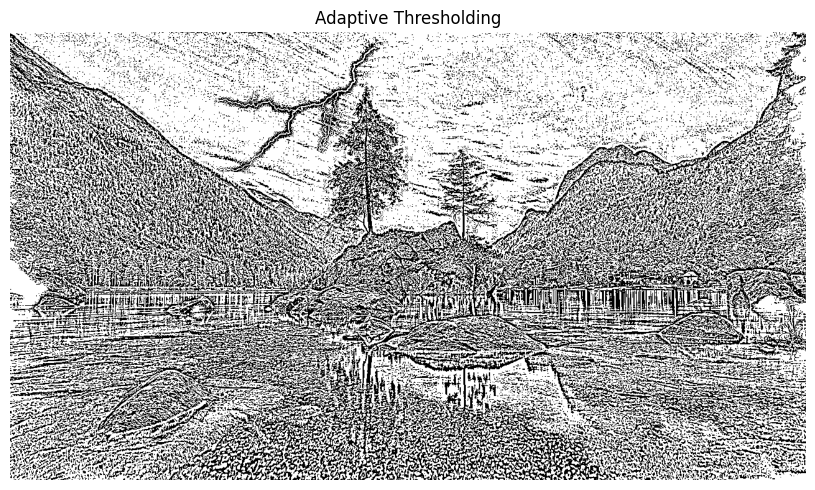

In [14]:
# Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(original_img, 255, 
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                        cv2.THRESH_BINARY, 11, 2)

print("Yash Agarwal 23BAI0011")
show_images([ adaptive_thresh], 
               [ 'Adaptive Thresholding'])

Yash Agarwal 23BAI0011


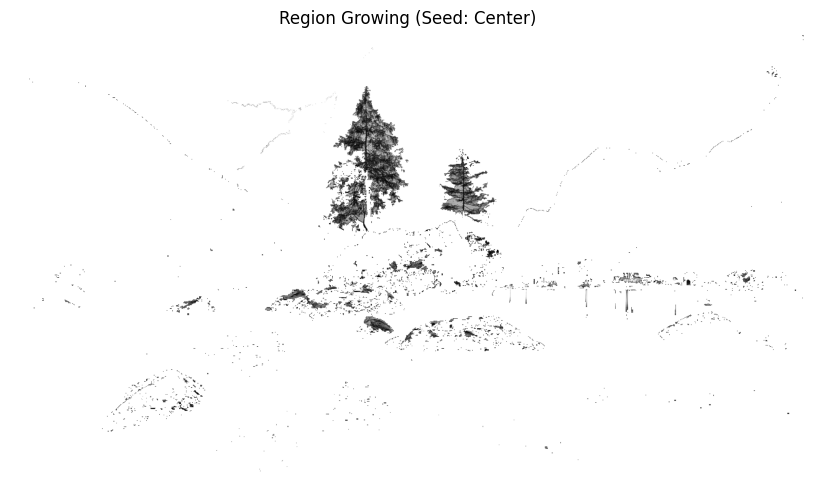

In [ ]:
reg_grow_img = original_img.copy()
h, w = original_img.shape[:2]

mask = np.zeros((h+2, w+2), np.uint8)

seed_point = (w//2, h//2)

loDiff = (20)
upDiff = (20)
new_val = 255 

# Apply Flood Fill
cv2.floodFill(reg_grow_img, mask, seed_point, new_val, loDiff=loDiff, upDiff=upDiff)

print("Yash Agarwal 23BAI0011")
show_images([reg_grow_img], 
               ['Region Growing (Seed: Center)'])

Yash Agarwal 23BAI0011


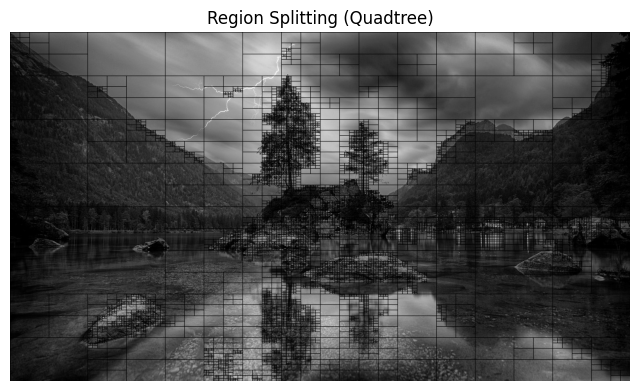

In [17]:
def split_image(img, x, y, w, h, threshold):
    roi = img[y:y+h, x:x+w]
    mean, stddev = cv2.meanStdDev(roi)

    if stddev[0][0] > threshold and w > 4 and h > 4:
        half_w = w // 2
        half_h = h // 2
        split_image(img, x, y, half_w, half_h, threshold)
        split_image(img, x + half_w, y, w - half_w, half_h, threshold)
        split_image(img, x, y + half_h, half_w, h - half_h, threshold)
        split_image(img, x + half_w, y + half_h, w - half_w, h - half_h, threshold)
    else:
        cv2.rectangle(output_split, (x, y), (x + w, y + h), (0, 0, 0), 1)

output_split = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)
threshold_val = 20  
split_image(original_img, 0, 0, original_img.shape[1], original_img.shape[0], threshold_val)

print("Yash Agarwal 23BAI0011")
plt.figure(figsize=(8,8))
plt.imshow(output_split)
plt.title("Region Splitting (Quadtree)")
plt.axis('off')
plt.show()

Yash Agarwal 23BAI0011


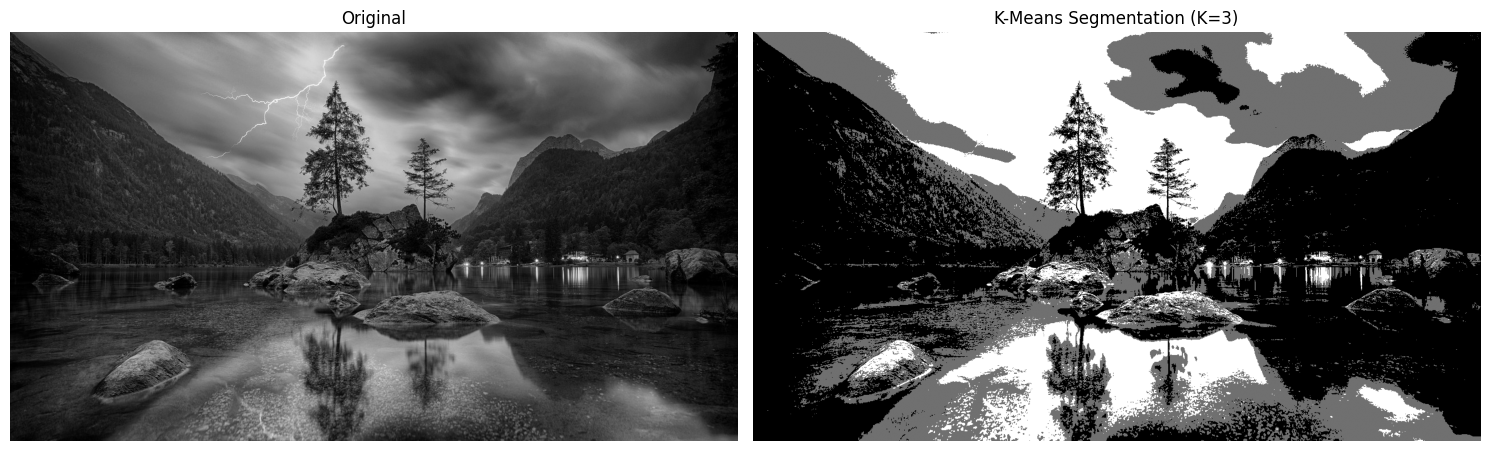

In [20]:
pixel_values = original_img.reshape((-1, 1))
pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

k = 3
_, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)

segmented_data = centers[labels.flatten()]
kmeans_img = segmented_data.reshape(original_img.shape)

print("Yash Agarwal 23BAI0011")
show_images([original_img, kmeans_img], 
               ['Original', f'K-Means Segmentation (K={k})'])